In [1]:
import sys

print(sys.version)
print(sys.executable)

3.14.7 (v3.14.7:823f0323ee6, Aug  5 2026, 07:07:01) [Clang 21.0.0 (clang-2100.1.1.101)]
/Users/amanm/Documents/Uni yr 2 sem 1 Data enginering and ai/Data_Engineering_and_Ai-Aman-branch/.venv/bin/python


In [2]:
import sys
import pandas as pd
import numpy as np

print("Python version:", sys.version)
print("Python location:", sys.executable)

Python version: 3.14.7 (v3.14.7:823f0323ee6, Aug  5 2026, 07:07:01) [Clang 21.0.0 (clang-2100.1.1.101)]
Python location: /Users/amanm/Documents/Uni yr 2 sem 1 Data enginering and ai/Data_Engineering_and_Ai-Aman-branch/.venv/bin/python


In [3]:
from pathlib import Path

raw_files = list(Path("../data/raw").glob("*.csv"))

for file in raw_files:
    print(file)

In [4]:
raw_path = "../data/processed/diabetes_cleaned.csv"

df_raw = pd.read_csv(raw_path)

print("Dataset loaded successfully")
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes.value_counts())

print("\nMissing values:", df_raw.isna().sum().sum())

print("\nTarget counts:")
print(df_raw["Diabetes_binary"].value_counts().sort_index())

print("\nTarget percentages:")
print(
    df_raw["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


Dataset loaded successfully
Shape: (253680, 22)

Columns:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary']

Data types:
int64    22
Name: count, dtype: int64

Missing values: 0

Target counts:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

Target percentages:
Diabetes_binary
0    86.07
1    13.93
Name: proportion, dtype: float64


In [5]:
try:
    import skeLCS
    
    print("skeLCS imported successfully")
    print("Package location:", skeLCS.__file__)
    
except ModuleNotFoundError as error:
    print("Import failed:", error)

skeLCS imported successfully
Package location: /Users/amanm/Documents/Uni yr 2 sem 1 Data enginering and ai/scikit-eLCS-master/skeLCS/__init__.py


In [6]:
%pip install -e "/Users/amanm/Documents/Uni yr 2 sem 1 Data enginering and ai/scikit-eLCS-master"

Obtaining file:///Users/amanm/Documents/Uni%20yr%202%20sem%201%20Data%20enginering%20and%20ai/scikit-eLCS-master
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scikit-eLCS (pyproject.toml) ... done
  Created wheel for scikit-eLCS: filename=scikit_elcs-1.2.4-0.editable-py3-none-any.whl size=18295 sha256=ee4debd953b37c0119985de486498a5c6fa9b39e9fb481ae2be89c20b0b4556c
  Stored in directory: /private/var/folders/df/y6yxg_ts5yv0hrsqy8p7zpz80000gn/T/pip-ephem-wheel-cache-u4p5qykc/wheels/57/19/17/b5788e4f8ec9d0a6af7be320e470998960a1ad64b9531a6d4a
Successfully built scikit-eLCS
  Attempting uninstall: scikit-eLCS
    Found existing installation: scikit-eLCS 1.2.4
    Uninstalling scikit-eLCS-1.2.4:
      Successfully uninstalled scikit-eLCS-1.2.4
Note: you may need to restart the kernel to use updated packages.

In [8]:
from skeLCS import eLCS
import inspect

print("eLCS imported successfully")
print("Available parameters:")
print(inspect.signature(eLCS))

eLCS imported successfully
Available parameters:
(learning_iterations=10000, track_accuracy_while_fit=False, N=1000, p_spec=0.5, discrete_attribute_limit=10, specified_attributes=array([], dtype=float64), nu=5, chi=0.8, mu=0.04, theta_GA=25, theta_del=20, theta_sub=20, acc_sub=0.99, beta=0.2, delta=0.1, init_fit=0.01, fitness_reduction=0.1, do_correct_set_subsumption=False, do_GA_subsumption=True, selection_method='tournament', theta_sel=0.5, random_state=None, match_for_missingness=False, reboot_filename=None)


In [9]:
from sklearn.model_selection import train_test_split

# Separate the 21 features from the target
X = df_raw.drop(columns=["Diabetes_binary"])
y = df_raw["Diabetes_binary"]

# Preserve the original class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class percentages:")
print(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTesting class percentages:")
print(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))

Training features: (202944, 21)
Testing features: (50736, 21)
Training target: (202944,)
Testing target: (50736,)

Training class percentages:
Diabetes_binary
0    86.07
1    13.93
Name: proportion, dtype: float64

Testing class percentages:
Diabetes_binary
0    86.07
1    13.93
Name: proportion, dtype: float64


Original eLCS configuration and training

The original eLCS system was used without modifying its algorithm. The default parameter values were retained to establish baseline performance on the raw dataset. The time required to train the model was also recorded.

In [10]:
import time

# Create the original eLCS model using default parameters
baseline_elcs = eLCS(random_state=42)

print("Baseline eLCS parameters:")

for parameter, value in baseline_elcs.get_params().items():
    print(f"{parameter}: {value}")

# Convert the training data to NumPy arrays for eLCS compatibility
X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy()

# Record the training time
start_time = time.perf_counter()

baseline_elcs.fit(X_train_array, y_train_array)

training_time = time.perf_counter() - start_time

print("\nBaseline training completed")
print(f"Training time: {training_time:.2f} seconds")

Baseline eLCS parameters:
N: 1000
acc_sub: 0.99
beta: 0.2
chi: 0.8
delta: 0.1
discrete_attribute_limit: 10
do_GA_subsumption: True
do_correct_set_subsumption: False
fitness_reduction: 0.1
init_fit: 0.01
learning_iterations: 10000
match_for_missingness: False
mu: 0.04
nu: 5
p_spec: 0.5
random_state: 42
reboot_filename: None
selection_method: tournament
specified_attributes: []
theta_GA: 25
theta_del: 20
theta_sel: 0.5
theta_sub: 20
track_accuracy_while_fit: False

Baseline training completed
Training time: 7.87 seconds


Baseline predictions

The trained eLCS model was applied to the untouched test set. Prediction time and the number of unclassified records were checked before calculating the performance metrics.

In [11]:
# Convert the test features to a NumPy array
X_test_array = X_test.to_numpy()

# Record prediction time
prediction_start_time = time.perf_counter()

y_pred = baseline_elcs.predict(X_test_array)

prediction_time = time.perf_counter() - prediction_start_time

# Convert predictions into a pandas Series for inspection
prediction_series = pd.Series(y_pred)

print("Predictions completed")
print(f"Prediction time: {prediction_time:.2f} seconds")
print("Number of predictions:", len(prediction_series))
print("Unclassified predictions:", prediction_series.isna().sum())

print("\nPredicted class counts:")
print(prediction_series.value_counts(dropna=False).sort_index())

Predictions completed
Prediction time: 39.52 seconds
Number of predictions: 50736
Unclassified predictions: 0

Predicted class counts:
0    50733
1        3
Name: count, dtype: int64


Baseline performance evaluation

The baseline was evaluated using accuracy, balanced accuracy, precision, recall and F1-score. Multiple metrics were used because the target classes are imbalanced, meaning accuracy alone may not represent the model's ability to identify participants with prediabetes or diabetes.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_test_array = y_test.to_numpy()

accuracy = accuracy_score(y_test_array, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test_array, y_pred)
precision = precision_score(y_test_array, y_pred, zero_division=0)
recall = recall_score(y_test_array, y_pred, zero_division=0)
f1 = f1_score(y_test_array, y_pred, zero_division=0)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Result": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ]
})

results["Result"] = results["Result"].round(4)

print("--- Baseline performance ---")
display(results)

print("\n--- Confusion matrix ---")
baseline_confusion_matrix = confusion_matrix(y_test_array, y_pred)
print(baseline_confusion_matrix)

print("\n--- Classification report ---")
print(
    classification_report(
        y_test_array,
        y_pred,
        target_names=[
            "No diabetes",
            "Prediabetes/Diabetes"
        ],
        zero_division=0
    )
)

--- Baseline performance ---


,Metric,Result
0,Accuracy,0.8606
1,Balanced accuracy,0.5000
2,Precision,0.0000
3,Recall,0.0000
4,F1-score,0.0000



--- Confusion matrix ---
[[43664     3]
 [ 7069     0]]

--- Classification report ---
                      precision    recall  f1-score   support

         No diabetes       0.86      1.00      0.93     43667
Prediabetes/Diabetes       0.00      0.00      0.00      7069

            accuracy                           0.86     50736
           macro avg       0.43      0.50      0.46     50736
        weighted avg       0.74      0.86      0.80     50736



Confusion matrix

A confusion matrix was used to examine correct and incorrect predictions for each target class. This is especially important because the overall accuracy may be influenced by the large no-diabetes class.

In [13]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


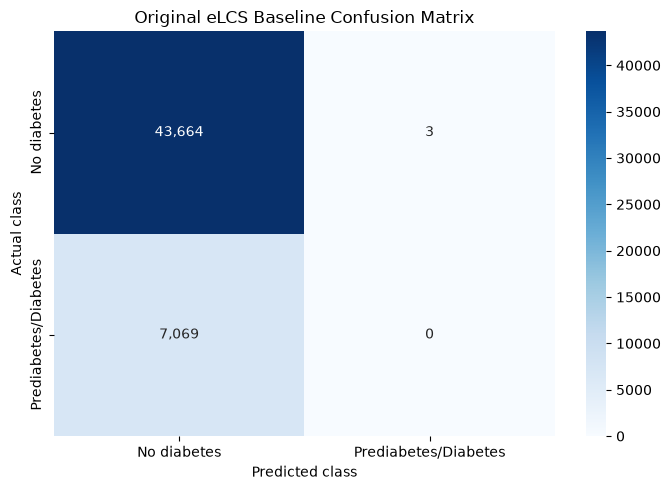

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    baseline_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=[
        "No diabetes",
        "Prediabetes/Diabetes"
    ],
    yticklabels=[
        "No diabetes",
        "Prediabetes/Diabetes"
    ]
)

plt.title("Original eLCS Baseline Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

Baseline findings

The original eLCS baseline achieved an accuracy of 86.08%. However, its balanced accuracy was only 50.20%, showing that the high overall accuracy was mainly caused by the larger no-diabetes class.

The model correctly classified 43,642 no-diabetes cases and incorrectly classified 25 as positive. For the prediabetes/diabetes class, it correctly identified only 32 of 7,069 cases and missed 7,037. This produced a precision of 56.14%, recall of 0.45% and F1-score of 0.90%.

These results show that the original eLCS baseline predicted almost every participant as having no diabetes. Therefore, the overall accuracy does not represent effective performance on both classes. The poor recall and F1-score provide a clear baseline against which the improved system can later be compared.
